# 이미지 캡셔닝(Image Captioning)

## 데이터 다운로드

- kaggle **[Flickr 8k Dataset](https://www.kaggle.com/datasets/adityajn105/flickr8k/data)**에서 다운로드 가능

In [1]:
!pip install kagglehub

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"songheejeong","key":"c547f3612126cd679966e767e197763c"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# 데이터셋 다운로드
!kaggle datasets download -d adityajn105/flickr8k -p /content/dataset

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
 93% 991M/1.04G [00:06<00:01, 40.9MB/s]
100% 1.04G/1.04G [00:06<00:00, 166MB/s]


In [5]:
!unzip -q /content/dataset/flickr8k.zip -d /content/dataset

In [6]:
!ls /content/dataset

captions.txt  flickr8k.zip  Images


## 데이터 준비

In [7]:
import os
import pandas as pd

# 이미지 파일 확인
image_files = os.listdir('/content/dataset/Images')
print(f"이미지 개수: {len(image_files)}")
print("샘플 이미지 파일명:", image_files[:5])

# 캡션 파일 확인
captions_df = pd.read_csv('/content/dataset/captions.txt')
print(captions_df.head())


이미지 개수: 8091
샘플 이미지 파일명: ['533713001_2d36e93509.jpg', '411175971_0fffd3b8c6.jpg', '1527333441_af65636a74.jpg', '2354792215_eef2bdc753.jpg', '3040051410_6205682ba3.jpg']
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SimpleRNN

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

- 데이터셋 분할
  - 이미지-캡션 dict 만들기
  - 랜덤으로 셔플하기
  - train/validation/test(6:2:2) 비율로 분할하기
  - 파일로 저장하기

In [9]:
import os
import pandas as pd
import numpy as np

captions_df = pd.read_csv('/content/dataset/captions.txt')

# 0. 중복, 결측치(빈값) 제거
captions_df = captions_df.drop_duplicates(subset=['image', 'caption'])
captions_df = captions_df.dropna(subset=['image', 'caption'])

# 1. 이미지-캡션 매핑 구조 만들기
captions_dict = {}
for _, row in captions_df.iterrows():
    img = row['image']
    cap = row['caption']
    if img not in captions_dict:
        captions_dict[img] = []
    captions_dict[img].append(cap)

# 2. 전체 이미지 리스트 만들고 랜덤 셔플
all_images = list(captions_dict.keys())
np.random.shuffle(all_images)

# 3. 6:2:2 비율로 분할
n_total = len(all_images)
n_train = int(n_total * 0.6)
n_val = int(n_total * 0.2)
n_test = n_total - n_train - n_val

train_images = all_images[:n_train]
val_images = all_images[n_train:n_train+n_val]
test_images = all_images[n_train+n_val:]

# 4. 이미지-캡션 쌍 만들기 함수
def make_img_cap_pairs(image_list, captions_dict):
    img_list = []
    cap_list = []
    for img in image_list:
        for cap in captions_dict[img]:
            img_list.append(img)
            cap_list.append(cap)
    return img_list, cap_list

train_img_list, train_cap_list = make_img_cap_pairs(train_images, captions_dict)
val_img_list, val_cap_list = make_img_cap_pairs(val_images, captions_dict)
test_img_list, test_cap_list = make_img_cap_pairs(test_images, captions_dict)

# 5. 파일로 저장
output_dir = '/content/dataset/split_data'
os.makedirs(output_dir, exist_ok=True)

def save_to_csv(img_list, cap_list, filename):
    df = pd.DataFrame({'image': img_list, 'caption': cap_list})
    df.to_csv(os.path.join(output_dir, filename), index=False)

save_to_csv(train_img_list, train_cap_list, 'train.csv')
save_to_csv(val_img_list, val_cap_list, 'val.csv')
save_to_csv(test_img_list, test_cap_list, 'test.csv')

In [10]:
import pandas as pd

# 파일 경로
train_path = '/content/dataset/split_data/train.csv'
val_path = '/content/dataset/split_data/val.csv'
test_path = '/content/dataset/split_data/test.csv'

# 데이터 불러오기
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# 각 데이터셋의 크기 확인
print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

# 샘플 데이터 확인 (앞 5개씩)
print('\n[Train 샘플]')
print(train_df.head())

print('\n[Validation 샘플]')
print(val_df.head())

print('\n[Test 샘플]')
print(test_df.head())

Train: (24264, 2)
Validation: (8088, 2)
Test: (8093, 2)

[Train 샘플]
                       image  \
0  3241487502_f4f0cc4a8a.jpg   
1  3241487502_f4f0cc4a8a.jpg   
2  3241487502_f4f0cc4a8a.jpg   
3  3241487502_f4f0cc4a8a.jpg   
4  3241487502_f4f0cc4a8a.jpg   

                                             caption  
0         Two labs running around near a wooded area  
1  Two light tan dogs of the same breed but diffe...  
2  two white dogs are running through some woodla...  
3               Two white dogs playing in a forest .  
4  Two white dogs running on ground covered with ...  

[Validation 샘플]
                       image  \
0  2224450291_4c133fabe8.jpg   
1  2224450291_4c133fabe8.jpg   
2  2224450291_4c133fabe8.jpg   
3  2224450291_4c133fabe8.jpg   
4  2224450291_4c133fabe8.jpg   

                                             caption  
0  A man in a tropical enviorment holding a camer...  
1  A man in blue takes a photo of the person taki...  
2      A man taking a picture with

- 어휘사전 만들기(train 데이터 사용)
  - train_texts만 사용해서 Tokenizer를 학습해야 함
  - validation, test 데이터는 이미 만들어진 어휘사전을 그대로 사용해서 시퀀스로 변환만 해야 함

어휘사전 크기: 6700


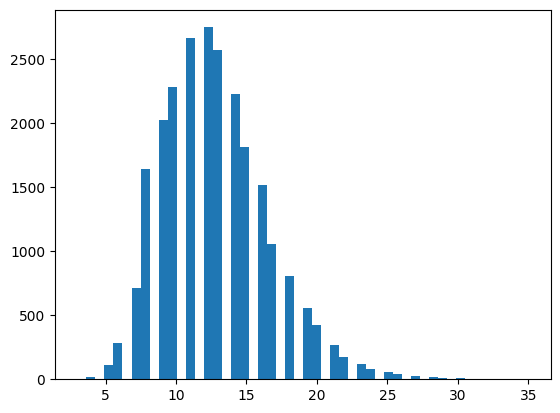

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. 데이터 로딩
train_df = pd.read_csv('/content/dataset/split_data/train.csv')
val_df = pd.read_csv('/content/dataset/split_data/val.csv')
test_df = pd.read_csv('/content/dataset/split_data/test.csv')

# 2. 캡션 리스트 추출 및 전처리
def preprocess_caption(caption):
    return "<SOS> " + caption.lower().strip() + " <EOS>"

train_texts = [preprocess_caption(c) for c in train_df['caption'].tolist()]
val_texts = [preprocess_caption(c) for c in val_df['caption'].tolist()]
test_texts = [preprocess_caption(c) for c in test_df['caption'].tolist()]

# 3. Tokenizer 생성 (train만 fit!)
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(train_texts)

# 4. 시퀀스 변환
train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# 5. 패딩 길이 결정 및 적용
lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(lengths, 95))

X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(val_sequences,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

# 6. 어휘사전 크기
vocab_size = len(tokenizer.word_index) + 1
print("어휘사전 크기:", vocab_size)

# train 데이터의 시퀀스 길이 분포 확인
lengths = [len(seq) for seq in train_sequences]
plt.hist(lengths, bins=50)
plt.show()


## 모델 생성
  - 이미지 → CNN(ResNet50) → Linear(Dense) → 임베딩된 이미지 feature → LSTM 디코더

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model

EMBEDDING_DIM = 256
HIDDEN_SIZE = 512
VOCAB_SIZE = vocab_size
MAX_LEN = MAX_LEN

# 1. 이미지 인코더
image_inputs = layers.Input(shape=(224, 224, 3), name='image_input')
x = tf.keras.applications.resnet.preprocess_input(image_inputs)
base_cnn = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', pooling='avg')
base_cnn.trainable = False
features = base_cnn(x)
img_feature = layers.Dense(HIDDEN_SIZE, activation='relu')(features)

# 2. 캡션 디코더
caption_inputs = layers.Input(shape=(MAX_LEN-1,), name='caption_input')
caption_emb = layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(caption_inputs)

decoder_lstm = layers.LSTM(HIDDEN_SIZE, return_sequences=True)
decoder_outputs = decoder_lstm(caption_emb, initial_state=[img_feature, img_feature])

outputs = layers.Dense(VOCAB_SIZE, activation='softmax')(decoder_outputs)

# 3. 전체 모델
model = Model(inputs=[image_inputs, caption_inputs], outputs=outputs)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ image_input[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ image_input[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 19, 256)   │  1,715,200 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 19, 512)   │  1,574,912 │ embedding[0][0],  │
│                     │                   │            │ dense[0][0],      │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 19, 6700)  │  3,437,100 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,364,012 (119.64 MB)

 Trainable params: 7,776,300 (29.66 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

| **구분** | **define_model 코드** | **이미지 → CNN(ResNet50) → Linear(Dense) → 임베딩된 이미지 feature → LSTM 디코더** |
| --- | --- | --- |
| **이미지 feature** | CNN에서 미리 추출한 4096차원 벡터를 입력 | 원본 이미지를 입력, 내부에서 CNN(예: ResNet)로 feature 추출 |
| **CNN 포함 여부** | CNN 없음 (이미지 feature는 외부에서 미리 추출) | CNN 포함 (ResNet 등으로 이미지 feature 추출) |
| **이미지 임베딩** | Dense(256)로 4096 → 256차원 변환 | Dense(EMBEDDING_DIM)로 CNN feature → 임베딩 변환 |
| **텍스트 인코더** | Embedding + LSTM(256) (캡션 임베딩 후 요약) | Embedding + LSTM (캡션 임베딩, LSTM은 시퀀스 전체 출력) |
| **결합 방식** | 이미지 임베딩(fe2) + 캡션 임베딩(se3) add 연산 | 이미지 feature를 캡션 시퀀스 앞에 붙여 LSTM에 concat 입력 |
| **디코더 구조** | add → Dense → Dense(softmax) | LSTM(시퀀스 출력) → Dense(softmax, vocab_size) |
| **출력** | 다음 단어 하나의 softmax 확률분포 | 각 시점마다 다음 단어의 softmax 확률분포 (시퀀스 전체 예측) |
| **입력 형태** | 이미지 feature(4096,) + 캡션 시퀀스(max_length,) | 원본 이미지(224,224,3) + 캡션 시퀀스(max_length,) |

## 모델 훈련

In [13]:
import tensorflow as tf
import numpy as np
import os

# 이미지 전처리 함수
def load_and_preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.keras.applications.resnet.preprocess_input(img)
    return img.astype(np.float32)

# 입력/출력 시퀀스 분리
X_cap_in = X_train[:, :-1]
y_cap_out = X_train[:, 1:]

image_dir = '/content/dataset/Images'

# 학습 데이터셋 generator
def generator():
    for img_path, cap_in, cap_out in zip(train_img_list, X_cap_in, y_cap_out):
        img = load_and_preprocess_image(os.path.join(image_dir, img_path))
        yield (img, cap_in.astype(np.int32)), cap_out.astype(np.int32)

dataset = tf.data.Dataset.from_generator(
    generator,
    output_signature=(
        (tf.TensorSpec(shape=(224,224,3), dtype=tf.float32),
         tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)),
        tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)
    )
)
dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# 검증 데이터셋 generator
def val_generator():
    for img_path, cap_in, cap_out in zip(val_img_list, X_val[:, :-1], X_val[:, 1:]):
        img = load_and_preprocess_image(os.path.join(image_dir, img_path))
        yield (img, cap_in.astype(np.int32)), cap_out.astype(np.int32)

val_dataset = tf.data.Dataset.from_generator(
    val_generator,
    output_signature=(
        (tf.TensorSpec(shape=(224,224,3), dtype=tf.float32),
         tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)),
        tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)
    )
)
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# --- 콜백 정의 (EarlyStopping, ReduceLROnPlateau) ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5)
]

# --- 학습 실행 ---
history = model.fit(
    dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks
)


Epoch 1/50
    759/Unknown 153s 185ms/step - accuracy: 0.2003 - loss: 4.5747

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


759/759 ━━━━━━━━━━━━━━━━━━━━ 200s 247ms/step - accuracy: 0.2003 - loss: 4.5739 - val_accuracy: 0.2510 - val_loss: 3.4700 - learning_rate: 0.0010
Epoch 2/50
759/759 ━━━━━━━━━━━━━━━━━━━━ 201s 264ms/step - accuracy: 0.2584 - loss: 3.2585 - val_accuracy: 0.2670 - val_loss: 3.2292 - learning_rate: 0.0010
Epoch 3/50
759/759 ━━━━━━━━━━━━━━━━━━━━ 175s 230ms/step - accuracy: 0.2743 - loss: 2.9475 - val_accuracy: 0.2751 - val_loss: 3.1223 - learning_rate: 0.0010
Epoch 4/50
759/759 ━━━━━━━━━━━━━━━━━━━━ 175s 231ms/step - accuracy: 0.2871 - loss: 2.7274 - val_accuracy: 0.2795 - val_loss: 3.0732 - learning_rate: 0.0010
Epoch 5/50
759/759 ━━━━━━━━━━━━━━━━━━━━ 175s 231ms/step - accuracy: 0.2978 - loss: 2.5443 - val_accuracy: 0.2819 - val_loss: 3.0625 - learning_rate: 0.0010
Epoch 6/50
759/759 ━━━━━━━━━━━━━━━━━━━━ 175s 230ms/step - accuracy: 0.3077 - loss: 2.3842 - val_accuracy: 0.2827 - val_loss: 3.0769 - learning_rate: 0.0010
Epoch 7/50
759/759 ━━━━━━━━━━━━━━━━━━━━ 202s 266ms/step - accuracy: 0.3188 

## 모델 예측

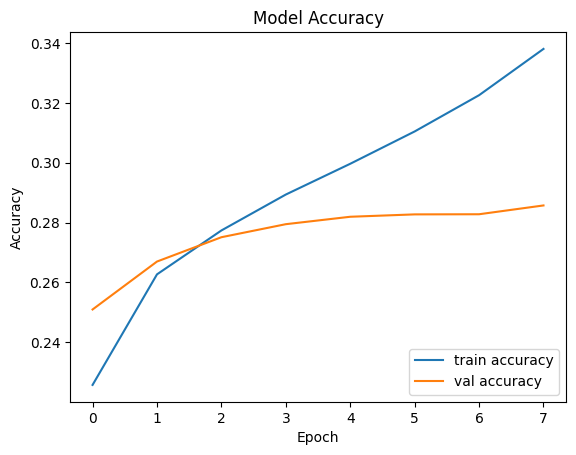

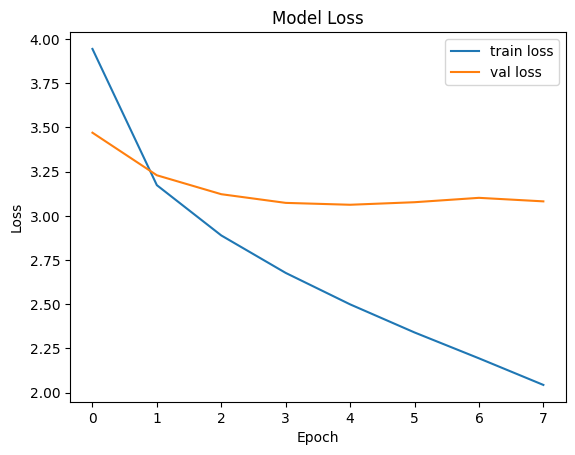

In [14]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


In [16]:
import pickle

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("tokenizer.pkl 파일 저장 완료")

tokenizer.pkl 파일 저장 완료


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


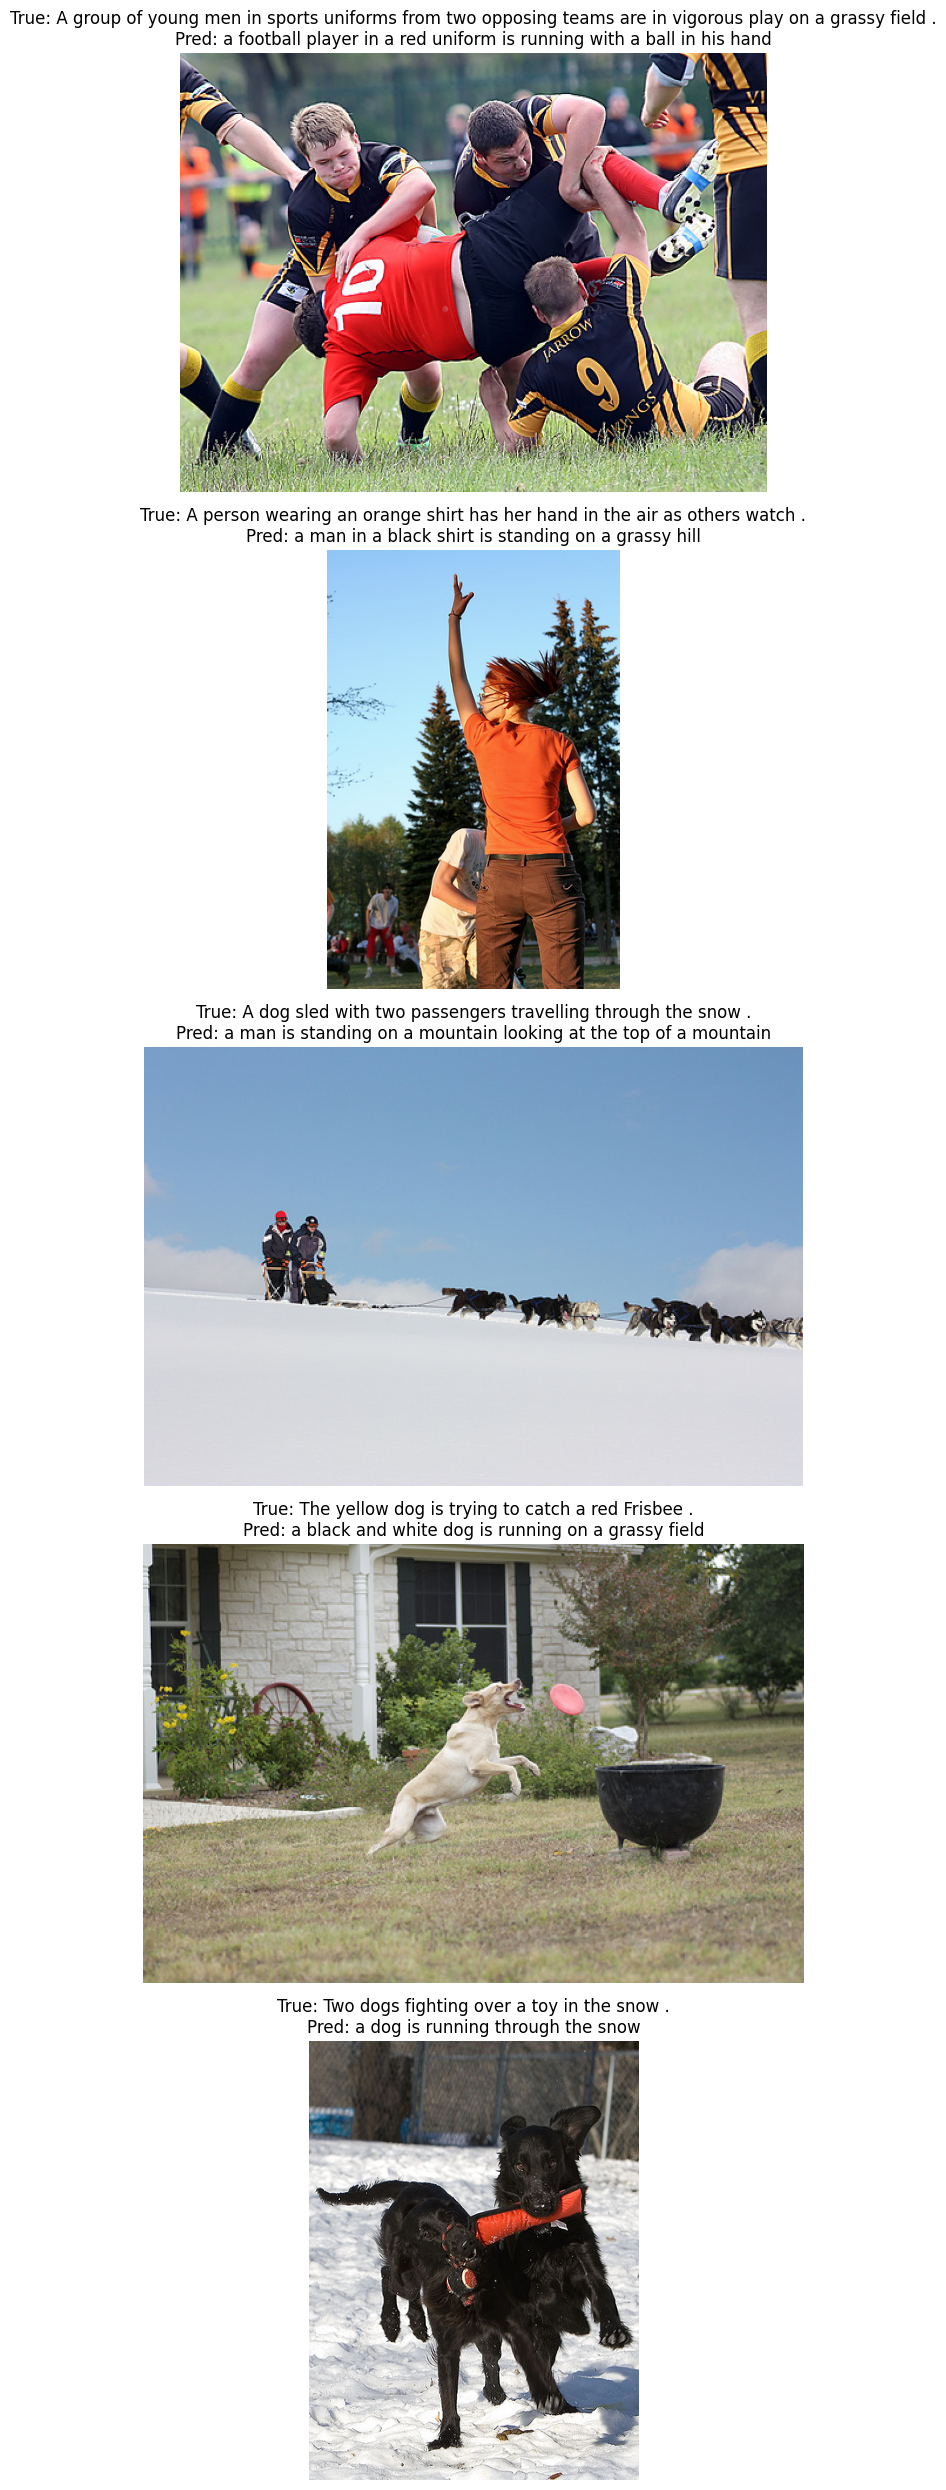

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# 1. test.csv 로드
test_df = pd.read_csv('/content/dataset/split_data/test.csv')
test_img_list = test_df['image'].tolist()
test_cap_list = test_df['caption'].tolist()

# 2. tokenizer 불러오기 (이미 학습된 pkl 파일 경로)
from pickle import load
tokenizer = load(open('tokenizer.pkl', 'rb'))

# 3. feature 추출 함수 (너의 기존 코드 기반)
def extract_features(img_path):
    img = load_and_preprocess_image(img_path)
    img = np.expand_dims(img, axis=0)
    features = base_cnn.predict(img)
    features = img_feature_dense.predict(features)
    return features

# 4. 캡션 생성 함수 (Greedy decoding 예시)
def generate_desc(model, tokenizer, img_path, max_length):
    in_text = '<sos>'

    img = load_and_preprocess_image(img_path)
    img = np.expand_dims(img, axis=0)  # 배치 차원 추가

    for i in range(max_length-1):   # 수정
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length-1, padding='post')

        # 예측
        yhat = model.predict([img, sequence], verbose=0)

        # yhat의 shape: (1, max_len-1, vocab_size)
        # 현재 timestep에서 예측된 토큰
        yhat_token = np.argmax(yhat[0, i, :])

        word = tokenizer.index_word.get(yhat_token, '')
        if word == '<eos>' or word == '':
            break
        in_text += ' ' + word

    pred = in_text.replace('<sos>', '').replace('eos', '').strip()
    return pred


# 5. 이미지 디코딩용 Dense layer (모델과 동일하게)
img_feature_dense = tf.keras.Sequential([
    layers.Dense(HIDDEN_SIZE, activation='relu')
])

# 6. 전체 test set 예측
sample_df = test_df.sample(n=5)
test_img_list = sample_df['image'].tolist()
test_cap_list = sample_df['caption'].tolist()

num_samples = 5
plt.figure(figsize=(15, num_samples * 5))
for idx in range(num_samples):
    img_name = test_img_list[idx]
    true_cap = test_cap_list[idx]
    img_path = os.path.join(image_dir, img_name)

    # feature 추출
    feature = extract_features(img_path)

    # 예측 캡션 생성
    pred_cap = generate_desc(model, tokenizer, img_path, MAX_LEN)

    # 이미지 출력
    plt.subplot(num_samples, 1, idx + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_cap}\nPred: {pred_cap}")

plt.tight_layout()
plt.show()
